# Урок 05. Цепное правило и backpropagation

> **Зачем это нужно:** backprop — это просто цепное правило, применённое к вычислительному графу. Если вы поймёте его руками, всё, что делает `loss.backward()` в PyTorch, перестанет быть магией.

---

## 1. Цепное правило (или правило дифференцирования сложной функции)  одной переменной

Если `y = f(g(x))`, то:

$$ \frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx} = f'(g(x)) \cdot g'(x) $$

Пример: `y = sin(x²)`. Внешняя функция `sin`, внутренняя `x²`.
`dy/dx = cos(x²) · 2x`.

In [1]:
import numpy as np

def f(x):
    return np.sin(x ** 2)

def df_analytic(x):
    return np.cos(x ** 2) * 2 * x

def df_numeric(x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

x = 1.5
print(df_analytic(x))
print(df_numeric(x))

-1.8845208681682175
-1.884520868128403


---

## 2. Цепное правило для композиции из 3+ функций

`y = h(g(f(x)))`:

$$ \frac{dy}{dx} = h'(g(f(x))) \cdot g'(f(x)) \cdot f'(x) $$

Это **умножение градиентов на каждом слое** — ровно то, что делает backprop.

---

# Связь цепного правила и алгоритма Backpropagation

Фраза **"умножение градиентов на каждом слое"** означает, что алгоритм обратного распространения ошибки (backpropagation) в нейросетях — это математическое цепное правило, примененное к цепочке слоев от конца к началу.

---

### 1. Нейросеть как цепочка функций
Когда нейросеть делает предсказание (прямой проход / forward pass), данные последовательно проходят через слои:
1. Входные данные $x$ поступают на **первый слой**: $f(x)$
2. Результат идет во **второй слой**: $g(f(x))$
3. Итоговый результат вычисляет **третий слой**: $y = h(g(f(x)))$

В самом конце вычисляется **ошибка** (Loss), которая показывает, насколько предсказание $y$ отличается от правильного ответа. Обозначим её как $L$. Таким образом, вся нейросеть представляет собой огромную композицию функций.

---

### 2. Зачем нейросети цепное правило?
Чтобы сеть училась, нам нужно узнать, как изменение весов на самом первом слое $f$ влияет на итоговую ошибку $L$ на выходе. Математически это поиск производной (градиента):

$$\frac{\partial L}{\partial x}$$

Прямой расчет этой величины для глубокой сети вычислительно неэффективен. Цепное правило позволяет разбить эту задачу на последовательность простых шагов.

---

### 3. Как работает «умножение градиентов» (Backprop)
Вместо того чтобы считать всё сразу, backprop движется **с конца** (от выхода к входу) и последовательно перемножает локальные производные каждого слоя:

1. **Выходной слой ($h$):** Считает, как его выход влияет на ошибку. Получаем градиент верхнего слоя.
2. **Скрытый слой ($g$):** Принимает градиент от слоя $h$ и **умножает** его на свою локальную производную $g'$.
3. **Входной слой ($f$):** Принимает накопленный результат и **умножает** на свою локальную производную $f'$.

В итоге градиент ошибки «прокатывается» обратно по всей цепочке через последовательное умножение:

$$\frac{\partial L}{\partial x} = h'(g(f(x))) \cdot g'(f(x)) \cdot f'(x)$$

$$\text{Итоговый градиент} = \text{Градиент}_{слой 3} \cdot \text{Градиент}_{слой 2} \cdot \text{Градиент}_{слой 1}$$

---

### 4. Почему это важно на практике?

* **Модульность:** Каждый слой должен знать производную *только своей собственной* функции. Ему не нужно знать архитектуру всей огромной сети. Он просто берет пришедший сверху градиент ошибки и умножает на свой локальный градиент.
* **Проблема затухания градиентов (Vanishing Gradient):** Из этой формулы очевидна главная уязвимость глубоких сетей. Если на нескольких слоях локальные градиенты будут очень маленькими (например, меньше $0.1$), то из-за постоянного **умножения** этих чисел друг на друга ($0.1 \cdot 0.1 \cdot 0.1 \dots$) итоговый градиент в начале сети превратится в ноль. В результате первые слои нейросети перестанут обучаться.


---
## 3. Вычислительный граф

Любое выражение разворачивается в граф элементарных операций. Пример: `L = (w·x + b - y)²`.

```
x ──┐
    × ──> z ──┐
w ──┘         + ──> u ──┐
              b ────────┘
                        - ──> e ──> ² ──> L
                  y ────┘
```

Чтобы найти `dL/dw`, идём от `L` назад к `w`, перемножая локальные производные.

---

### 1. Прямой проход (Forward Pass): Слева направо
Компьютер разбивает выражение на **4 элементарные операции** (узлы графа) и вычисляет их последовательно:

1. **Узел `×` (Умножение):** Берет входные данные $x$ и вес $w$, перемножает их.  
   $$\text{Формула: } z = w \cdot x$$
2. **Узел `+` (Сложение):** Добавляет к результату сдвиг (bias) $b$. Получается предсказание нейрона.  
   $$\text{Формула: } u = z + b$$
3. **Узел `-` (Вычитание):** Вычитает из предсказания $u$ правильный ответ $y$. Так вычисляется чистая ошибка (error).  
   $$\text{Формула: } e = u - y$$
4. **Узел `²` (Квадрат):** Возводит ошибку $e$ в квадрат, чтобы значение лосса всегда было положительным.  
   $$\text{Формула: } L = e^2$$

---

### 2. Обратный проход (Backpropagation): Справа налево
Чтобы обновить вес $w$ и обучить нейросеть, алгоритм движется в обратную сторону по цепочке от $L$ к $w$. Согласно **цепному правилу**, итоговый градиент — это произведение локальных производных каждого узла:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial e} \cdot \frac{\partial e}{\partial u} \cdot \frac{\partial u}{\partial z} \cdot \frac{\partial z}{\partial w}$$

Каждый узел отвечает только за свою простую операцию:
1. **Узел `²`** знает, что производная от $e^2$ равна $2e$. Он передает налево градиент: $\mathbf{2e}$.
2. **Узел `-`** знает, что производная $e = u - y$ по переменной $u$ равна $1$. Он умножает пришедший сигнал на 1: $2e \cdot 1 = \mathbf{2e}$.
3. **Узел `+`** знает, что производная $u = z + b$ по переменной $z$ равна $1$. Он снова умножает на 1: $2e \cdot 1 = \mathbf{2e}$.
4. **Узел `×`** знает, что производная $z = w \cdot x$ по переменной $w$ равна $x$. Он умножает накопленный результат на $x$: $\mathbf{2e \cdot x}$.

---

### ✅ Итог

В крайней левой точке для веса $w$ компьютер получает готовый точный градиент:
$$\frac{\partial L}{\partial w} = 2e \cdot x = 2(w \cdot x + b - y) \cdot x$$

Библиотекам автоматического дифференцирования (PyTorch, TensorFlow) не нужно знать сложные правила раскрытия скобок. Они просто выполняют цепочку простейших шагов: 
$$\text{Умножить на } 2e \rightarrow \text{Умножить на } 1 \rightarrow \text{Умножить на } 1 \rightarrow \text{Умножить на } x$$

---
---
## 4. Backprop руками: ручной вывод для одного нейрона

Дано: `z = wx + b`, `a = σ(z)`, `L = (a - y)²`.

Цель: найти `dL/dw`, `dL/db`.

**Forward pass:**

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

w, b, x, y = 0.5, 0.1, 2.0, 1.0
z = w * x + b
a = sigmoid(z)
L = (a - y) ** 2

**Backward pass** (применяем цепное правило шаг за шагом):

In [3]:
dL_da = 2 * (a - y)
da_dz = a * (1 - a)
dz_dw = x
dz_db = 1

dL_dw = dL_da * da_dz * dz_dw
dL_db = dL_da * da_dz * dz_db

print(dL_dw)
print(dL_db)

-0.1871749357314132
-0.0935874678657066



Это весь backprop. Дальше — просто больше переменных и операция `@` вместо `*`.

---
## 5. Backprop для двухслойной сети

Архитектура: `h = ReLU(W₁x + b₁)`, `o = W₂h + b₂`, `L = (o - y)²`.

In [4]:
def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

# Forward
z1 = W1 @ x + b1
h = relu(z1)
o = W2 @ h + b2
L = (o - y) ** 2

# Backward
# === ЗОНА ВТОРОГО СЛОЯ (Выходного) ===
# Мы работаем только с ошибкой прогноза (dL_do) и выходом скрытого слоя (h)
dL_do = 2 * (o - y)
dL_dW2 = np.outer(dL_do, h)
dL_db2 = dL_do

# ─── ГРАНИЦА: Ошибка "перепрыгивает" со 2-го слоя на 1-й ───
dL_dh = W2.T @ dL_do  # Мы умножили ошибку на веса W2. С этого момента мы в Слыое 1!

# === ЗОНА ПЕРВОГО СЛОЯ (Скрытого) ===
# Теперь мы работаем с ошибкой, пришедшей на этот слой (dL_dh), и его входами (x)
dL_dz1 = dL_dh * relu_grad(z1)
dL_dW1 = np.outer(dL_dz1, x)
dL_db1 = dL_dz1


NameError: name 'W1' is not defined

Это **полный backprop руками**, без `autograd`. На этом построены все фреймворки.

---

# Математическое разложение градиентов по цепному правилу

Ниже показано, как каждый из вычисленных в коде градиентов раскладывается в полную математическую цепочку (от выхода сети к её началу) через последовательное умножение локальных производных.

---

### 1. Выходной слой (Слой 2)

* **Базовый сигнал ошибки на выходе сети (`dL_do`):**
  $$\text{dL\_do} = \frac{\partial L}{\partial o} = 2(o - y)$$

* **Градиент для весов второго слоя (`dL_dW2`):**
  $$\text{dL\_dW2} = \frac{\partial L}{\partial W_2} = \text{np.outer}\left( \underbrace{2(o - y)}_{\text{dL\_do}}, \, h \right)$$

* **Градиент для сдвигов второго слоя (`dL_db2`):**
  $$\text{dL\_db2} = \frac{\partial L}{\partial b_2} = \underbrace{2(o - y)}_{\text{dL\_do}}$$

---

### 2. Скрытый слой (Слой 1)

* **Ошибка, перенесенная на скрытый слой (`dL_dh`):**
  $$\text{dL\_dh} = \frac{\partial L}{\partial h} = W_2^T \cdot \underbrace{2(o - y)}_{\text{dL\_do}}$$

* **Градиент до функции активации ReLU (`dL_dz1`):**
  $$\text{dL\_dz1} = \frac{\partial L}{\partial z_1} = \underbrace{\left( W_2^T \cdot \underbrace{2(o - y)}_{\text{dL\_do}} \right)}_{\text{dL\_dh}} * \text{relu\_grad}(z_1)$$

* **Градиент для весов первого слоя (`dL_dW1`):**
  $$\text{dL\_dW1} = \frac{\partial L}{\partial W_1} = \text{np.outer}\left( \underbrace{\underbrace{\left( W_2^T \cdot \underbrace{2(o - y)}_{\text{dL\_do}} \right)}_{\text{dL\_dh}} * \text{relu\_grad}(z_1)}_{\text{dL\_dz1}}, \, x \right)$$

* **Градиент для сдвигов первого слоя (`dL_db1`):**
  $$\text{dL\_db1} = \frac{\partial L}{\partial b_1} = \underbrace{\underbrace{\left( W_2^T \cdot \underbrace{2(o - y)}_{\text{dL\_do}} \right)}_{\text{dL\_dh}} * \text{relu\_grad}(z_1)}_{\text{dL\_dz1}}$$

---

### 💡 Главный вывод
Посмотрите на формулу весов первого слоя (`dL_dW1`). Чтобы обновить параметры в самом начале сети, компьютеру пришлось «протащить» градиент через все последующие слои: 
$$\text{Ошибка прогноза } 2(o-y) \rightarrow \text{Умножение на веса } W_2^T \rightarrow \text{Фильтрация через } \text{relu\_grad}(z_1) \rightarrow \text{Связь со входом } x$$

Знаки умножения наглядно показывают разницу в операциях:
* **`@` и `W2.T ·`** — матричное умножение (изменяет размерность, передавая ошибку между слоями).
* **`*`** — поэлементное умножение (применяется к независимым нейронам внутри одного слоя, как в ReLU).
* **`np.outer`** — внешнее произведение векторов (строит двумерную матрицу градиентов весов).


# Как понять, где заканчивается Второй слой и начинается Первый?

Граница между слоями становится очевидной, если посмотреть на **направление движения данных**. В нейросетях оно строго противоположное для прогноза и для обучения.

---

### 1. При прямом проходе (Forward Pass): Слева направо
Данные идут строго по порядку: **от входа к выходу** (Слой 1 $\rightarrow$ Слой 2). 

Граница — это момент, когда вы получили **выход скрытого слоя $h$** и передали его дальше:
* **Всё, что до $h$** (включая саму активацию ReLU) — это **Первый слой**. Он работает с исходным входом $x$.
* **Всё, что после $h$** — это **Второй слой**. Он принимает $h$ как входные данные и делает из них финальный прогноз $o$.
---

### 2. При обратном проходе (Backward Pass): Справа налево
Ошибки идут в обратную сторону: **от лосса к входу** (Слой 2 \(\rightarrow\) Слой 1). 

Граница между слоями в коде — это **перенос ошибки через веса с помощью операции `W2.T @ dL_do`**. 

---

### 💡 Простая шпаргалка для сканирования кода

Вы точно перешли из Второго слоя в Первый, если:
1. В формулах **исчезла переменная $h$** (выход скрытого слоя) и **появилась переменная $x$** (вход всей сети).
2. Вы применили **`W2.T @`**. Эта операция меняет размерность вектора ошибки: переводит его из пространства выходных нейронов в пространство скрытых нейронов.
3. Вы начали умножать на **`relu_grad(z1)`**. Так как ReLU «живет» на первом слое, то и её производная применяется только тогда, когда ошибка докатилась обратно до первого слоя.



---
---
---
# Нейросети с нуля: от одного нейрона до двухслойной сети

Давайте отложим в сторону сложный код и формулы. Представим, что мы строим систему с нуля, и пройдем этот путь по шагам: от одного самого простого «кирпичика» до полноценной двухслойной сети.

---

### Шаг 1. Начнем с одного нейрона (Линейная регрессия)

Нейрон — это просто математический предсказатель. Представим, что мы хотим предсказать **стоимость квартиры**.
У нас есть один входной признак:
* $x$ — **площадь квартиры** (например, 50 кв.м).

Как нейрон делает прогноз? У него есть два секретных числа, которые он настраивает в процессе учебы:
1. $w$ (**вес**) — насколько сильно площадь влияет на цену.
2. $b$ (**сдвиг / bias**) — базовая стоимость, ниже которой квартир не бывает.

Нейрон берет площадь, умножает на вес и прибавляет сдвиг:
$$\text{Прогноз} = w \cdot x + b$$

---

### Шаг 2. Почему одного нейрона мало? (Проблема нелинейности)

Жизнь устроена сложно. Цена квартиры растет не просто по прямой линии. Маленькие квартиры могут стоить дешевле пропорционально, а огромные пентхаусы — в разы дороже. График реальной жизни **кривой (нелинейный)**.

А формула $w \cdot x + b$ умеет рисовать только **идеально прямые линии**. Чтобы согнуть эту линию и подстроить под реальный мир, математики придумали **функции активации**. 

Самая популярная — **ReLU**. Она делает простую вещь:
* Если число получилось отрицательным, она превращает его в $0$.
* Если число положительное, она оставляет его как есть.

Эта копеечная операция (срезать всё, что меньше нуля) превращает прямую линию в гибкий график с изломами.

---

### Шаг 3. Что такое Двухслойная нейросеть?

Один нейрон может выучить только одну простую закономерность. А если мы объединим много нейронов вместе?

**Двухслойная сеть** — это когда мы строим «конвейер» из двух этапов (слоев) нейронов:

1. **Первый слой (Скрытый слой):**
   Мы берем наш вход $x$ (площадь) и отдаем его сразу нескольким нейронам (например, трем). Каждый из них считает что-то свое со своими весами $W_1$ и сдвигами $b_1$. 
   Затем мы пропускаем их ответы через **ReLU**, чтобы «искривить» их. Получается промежуточный результат — вектор $h$ (от слова hidden — скрытый).
   
2. **Второй слой (Выходной слой):**
   Мы берем эти три «скрытых» ответа $h$ and передаем их финальному нейрону. Он объединяет их (умножает на свои веса $W_2$ и прибавляет $b_2$), чтобы выдать ОДНО итоговое число — окончательный **Прогноз** ($o$).

Поздравляю, это и есть **двухслойная сеть**! Слои считаются по количеству этапов с весами (вход $x$ весов не имеет, поэтому он слоем не считается).

---

### Шаг 4. Как она понимает, что ошиблась? (Функция потерь / Loss)

Сначала веса в сети случайные, поэтому сеть выдает полную глупость. Например, квартира стоит 10 миллионов ($y$), а сеть говорит: «2 миллиона» ($o$).

Чтобы компьютер понял масштаб катастрофы, мы считаем ошибку по формуле **MSE (Mean Squared Error)**:
$$L = (o - y)^2$$
Мы вычитаем из прогноза правильный ответ и возводим в квадрат. Чем больше это число $L$, тем хуже работает наша сеть.

---

### Шаг 5. Как её обучить? (Backpropagation и Цепное правило)

Цель обучения — изменить веса в **Слое 1** и **Слое 2** так, чтобы ошибка $L$ стала как можно меньше.

Для этого нам нужно узнать: *«Если я изменю вот этот конкретный вес, как сильно изменится ошибка?»*. Ответ на этот вопрос в математике называется **производной (или градиентом)**.

But как узнать, как вес из самого начала (Слой 1) влияет на ошибку в самом конце? 
Здесь и включается **цепное правило**:
1. Мы смотрим, как прогноз ($o$) повлиял на ошибку $L$. (Ищем производную на выходе).
2. Прокатываемся назад во **Второй слой** и меняем его веса $W_2$.
3. Прокатываемся еще дальше назад через **ReLU** в **Первый слой** и меняем его веса $W_1$.

Ошибка катится назад, как ком с горы, последовательно **перемножая** влияние каждого слоя. Этот процесс движения задом наперед и называется **Backpropagation (обратное распространение ошибки)**.


---
---
---

# 📌 Итоговая шпаргалка: Как связаны Backprop и Градиентный спуск?

Чтобы нейросеть успешно обучалась, два этих алгоритма работают в неразрывной связке как единый конвейер. Их часто путают, но у них принципиально разные роли.

Если коротко: **Backprop — это глаза системы (поиск проблемы), а Градиентный спуск — это её руки (исправление весов).**

---

### 🧱 Разделение обязанностей

#### 1. Backpropagation (Обратное распространение ошибки)
* **Его задача:** Только **рассчитать** градиенты (производные) для каждого веса в сети.
* **Как он это делает:** Движется с конца сети к началу по вычислительному графу и использует **цепное правило**. Он последовательно перемножает локальные производные слоев, создавая «ком ошибок».
* **Результат работы:** На выходе мы получаем точные значения `dL_dW1` и `dL_dW2`. Но сам Backprop **не меняет** веса. Он просто говорит: *«Если мы изменим этот вес на единицу, ошибка изменится вот на столько-то»*.

#### 2. Gradient Descent (Градиентный спуск)
* **Его задача:** Используя данные от Backprop, физически **изменить (обновить)** веса в памяти компьютера, чтобы уменьшить общую ошибку.
* **Как он это делает:** Он берет рассчитанный градиент, умножает его на скорость обучения (`learning_rate`) и вычитает полученное значение из текущего веса. Знак минус нужен для того, чтобы идти против роста ошибки (вниз к минимуму).
* **Результат работы:** Веса $W_1$ и $W_2$ перезаписываются на новые, более точные значения.

---

### 🔄 Полный цикл обучения (Один шаг/Эпоха)

Вся магия нейросетей укладывается в циклическое повторение четырех простых шагов:

1. **Forward (Прямой проход):** Данные $x$ идут слева направо. Сеть делает прогноз $o$ и вычисляет ошибку $L = (o - y)^2$.
2. **Backward / Backprop:** Ошибка катится справа налево. Компьютер перемножает градиенты и выясняет персональную ответственность каждого веса за итоговый косяк (`dL_dW1`, `dL_dW2`).
3. **Update (Градиентный спуск):** Компьютер крутит ручки настроек по формуле: $W = W - \text{lr} \cdot dL\_dW$.
4. **Repeat:** Мы берем следующий пример данных и повторяем всё заново.

Через тысячи таких циклов веса настраиваются идеально, «эхо ошибки» затихает, и сеть начинает выдавать безошибочные прогнозы.


---
# 🎯 Главный инсайт: Ради чего мы всё это делаем?

Вы абсолютно правы! Весь этот сложный обратный проход (Backprop), вычисление «кома ошибок», проталкивание градиентов через матрицы весов и фильтр ReLU — всё это делается исключительно ради двух главных величин: **`dL_dW2`** и **`dL_dW1`** (а также их компаньонов для сдвигов `dL_db2` и `dL_db1`).

Вот почему это фундаментальная истина архитектуры нейросетей:

### 1. Веса — это единственное, чем мы можем управлять
В нейросети есть три типа данных:
1. **Входы (x) и правильные ответы (y):** Это жесткие данные из реального мира. Мы не имеем права их менять. Квартира не станет меньше площадью просто потому, что сети так удобно.
2. **Промежуточные значения (z₁, h, o):** Это просто временные числа, которые автоматически получаются в процессе расчета. Они намертво связаны со входами и текущими весами.
3. **Веса и сдвиги (W₁, W₂, b₁, b₂):** Это **единственные «ручки настройки»**, которые физически принадлежат самой нейросети. Это её память, её опыт и её интеллект. Изменяя их, мы меняем поведение всей сети.

---

### 2. Зачем тогда нам промежуточные градиенты (вроде `dL_dh`)?
Вы можете спросить: *«Если нас интересуют только веса, зачем мы вообще считали `dL_dh` (градиент по скрытому слою)?»*.

Ответ: **Исключительно как инструмент.** 
`dL_dh` — это не цель, это мост. Мы не можем изменить значения в скрытом слое h напрямую. Но нам математически необходимо рассчитать `dL_dh`, чтобы по цепному правилу «дотянуться» до весов первого слоя `dL_dW1`, которые стоят еще глубже. Как только мы использовали `dL_dh` для расчета `dL_dW1`, это промежуточное число компьютеру больше не нужно, и он мгновенно стирает его из оперативной памяти.

---

### 3. Финал всей операции
Как только Backprop завершен, у компьютера на руках остаются те самые заветные **`dL_dW2`** и **`dL_dW1`**. Он тут же передает их алгоритму Градиентного спуска, который выполняет главное действие, ради которого и строился весь вычислительный граф:

```python
W2 = W2 - lr * dL_dW2  # Физически изменили настройки 2-го слоя
W1 = W1 - lr * dL_dW1  # Физически изменили настройки 1-го слоя
```

Все остальные временные градиенты (`dL_do`, `dL_dh`, `dL_dz1`) просто выбрасываются в корзину. Сеть успешно сделала один микро-шаг к тому, чтобы стать умнее.


---
---
# 🗺️ Геометрия графа, полный дифференциал и язык кода

Чтобы математика обратного распространения ошибки (Backpropagation) перестала казаться «магией», необходимо строго разобрать два аспекта: геометрию потоков данных в компьютере и математический фундамент, на котором строятся формулы.

---

### Часть 1. Что значит «справа» и «слева»? (Геометрия графа)

Вычислительный граф в памяти компьютера всегда располагается горизонтально. Прямой проход (**Forward**) мы читаем как обычный текст: **слева направо**.

Рассмотрим изолированный узел умножения, который вычисляет значение $z = w \cdot x$:

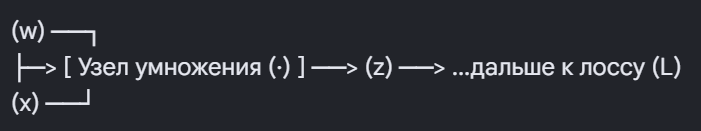

* **«Слева» от узла** находятся его **входы** ($w$ и $x$). Они подаются в операцию с левой стороны.
* **«Справа» от узла** находится его **выход** ($z$). Он выходит из узла направо и течет дальше по сети к финальной ошибке (лоссу) $L$.

#### Обратный проход (Backward):
При обучении мы разворачиваемся и идем в противоположную сторону — **справа налево** (от финального лосса $L$ обратно к началу сети).

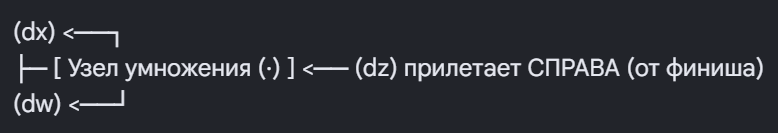

1. **«Справа прилетает» (`dz`):** Из глубин сети (со стороны финальной ошибки $$(L))$$ в наш узел возвращается число. Математически это частная производная $$ (\frac{\partial L}{\partial z})$$. Она показывает: *«Вот так глобальная ошибка всей сети реагирует на изменение выхода твоего маленького узла»*.
2. **«Уходит налево» (`dx`, `dw`):** Наш узел принимает это число, пересчитывает по правилам дифференцирования и отдает назад своим входам, которые стоят **слева** от него.

---

### Часть 2. Разница между математическим символом и кодом

Очень часто возникает путаница: *почему частная производная $$(\frac{\partial L}{\partial x})$$ в таблицах вдруг приравнивается к дифференциалу $$(dx)$$?* 

Это исключительно **совпадение имён** в программировании и чистой математике:
1. В **классической математике** символ $$(dx)$$ — это *дифференциал* (бесконечно малое приращение переменной $$(x)$$).
2. В **коде нейросетей** буквой `d` просто сокращают слово **Derivative** (производная). 

Когда вы видите в коде или в таблицах переменную `dx`, это **НЕ** математический дифференциал. Это просто короткое имя переменной, внутри которой лежит **вся частная производная целиком**:

$$[\text{Переменная в коде } \texttt{dx} = \frac{\partial L}{\partial x}]$$
$$[\text{Переменная в коде } \texttt{dz} = \frac{\partial L}{\partial z}]$$

Перепишем математическое цепное правило и сопоставим его с кодом:

$$[\underbrace{\frac{\partial L}{\partial x}}_{\texttt{dx}} = \underbrace{\frac{\partial L}{\partial z}}_{\texttt{dz}} \cdot \frac{\partial z}{\partial x} \implies \texttt{dx} = \texttt{dz} \cdot \frac{\partial z}{\partial x}]$$

---

### Часть 3. Откуда берутся формулы? Вывод через полный дифференциал

В основе Backpropagation лежит инвариантность формы **полного дифференциала**. Выведем правила обратного прохода строго.

#### 1. Случай одной переменной (например, $$(z = f(x)))$$
Мы хотим узнать, как микро-сдвиг переменной $$(x)$$ изменит итоговый лосс $$(L)$$. По определению дифференциала для финального лосса $$(L)$$:
$$[dL = \frac{\partial L}{\partial x} \cdot dx]$$

Но переменная $$(x)$$ влияет на лосс не напрямую, а через выход узла $$(z)$$. Запишем дифференциал лосса через переменную $$(z)$$:
$$[dL = \frac{\partial L}{\partial z} \cdot dz]$$

Теперь распишем дифференциал самого узла $$(z = f(x))$$:
$$[dz = \frac{\partial z}{\partial x} \cdot dx]$$

Подставим выражение для $$(dz)$$ в формулу для $$(dL)$$:
$$[dL = \frac{\partial L}{\partial z} \cdot \left( \frac{\partial z}{\partial x} \cdot dx \right) = \left( \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial x} \right) \cdot dx]$$

Сравнивая самый первый дифференциал $$(dL = \frac{\partial L}{\partial x} \cdot dx)$$ с полученным результатом, мы видим тождество:
$$[\frac{\partial L}{\partial x} = \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial x}]$$

#### 2. Случай двух переменных (например, Сложение или Умножение $$(z = f(x, y)))$$
Если узел зависит от двух входов, то полный дифференциал для $$(z)$$ равен:
$$[dz = \frac{\partial z}{\partial x} \cdot dx + \frac{\partial z}{\partial y} \cdot dy]$$

Подставим этот полный дифференциал в формулу ошибки $$(dL = \frac{\partial L}{\partial z} \cdot dz)$$:
$$[dL = \frac{\partial L}{\partial z} \cdot \left( \frac{\partial z}{\partial x} \cdot dx + \frac{\partial z}{\partial y} \cdot dy \right)]$$

Раскроем скобки:
$$[dL = \left( \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial x} \right) \cdot dx + \left( \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial y} \right) \cdot dy]$$

По определению, независимый полный дифференциал функции $$(L(x, y))$$ выглядит так:
$$[dL = \frac{\partial L}{\partial x} \cdot dx + \frac{\partial L}{\partial y} \cdot dy]$$

Сравнивая коэффициенты перед $$(dx)$$ и $$(dy)$$ в двух последних уравнениях, мы получаем строгие формулы для Backprop:
$$[\frac{\partial L}{\partial x} = \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial x}]$$
$$[\frac{\partial L}{\partial y} = \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial y}]$$

---

### 🛠️ Пример: Строгий вывод для узла умножения $$(z = x \cdot y)$$

1. Находим локальные частные производные функции внутри узла:
   $$[\frac{\partial z}{\partial x} = y, \quad \frac{\partial z}{\partial y} = x]$$

2. Подставляем их в наши выведенные через полный дифференциал формулы:
   $$[\frac{\partial L}{\partial x} = \frac{\partial L}{\partial z} \cdot y]$$
   $$[\frac{\partial L}{\partial y} = \frac{\partial L}{\partial z} \cdot x]$$

3. Переводим строгую математику на чистый язык кода (заменяя $$(\frac{\partial L}{\partial \bullet})$$ на переменные `d...`):
   ```python
   dx = dz * y
   dy = dz * x
   ```
Переменные просто поменялись местами. Градиент для $x$ — это пришедшая справа ошибка, умноженная на соседа $y$.


### 📋 Справочная таблица элементарных операций Backpropagation

В таблице ниже приведена математическая основа автоматического дифференцирования. 
* **Forward** показывает, как вычисляется значение при движении слева направо.
* **Backward** показывает, как прилетевший справа «ком ошибок» $dz$ (то есть $\frac{\partial L}{\partial z}$) превращается в локальные градиенты для входов (передается налево).

| Операция | Forward (Прямой проход) | Backward (Обратный проход для входов) |
| :--- | :--- | :--- |
| **Сложение** | $z = x + y$ | $dx = dz$, <br> $dy = dz$ |
| **Умножение** | $z = x \cdot y$ | $dx = y \cdot dz$, <br> $dy = x \cdot dz$ |
| **Максимум** | $z = \max(x, y)$ | $dx = dz$, если $x > y$, иначе $0$ <br> $dy = dz$, если $y > x$, иначе $0$ |
| **Экспонента** | $z = \exp(x)$ | $dx = \exp(x) \cdot dz$ |
| **Логарифм** | $z = \log(x)$ | $dx = \frac{1}{x} \cdot dz$ |
| **Матричное умножение** | $z = W @  x$ | $dW = dz @ x^T$, <br> $dx = W^T @ dz$ |
| **Активация ReLU** | $z = \text{ReLU}(x)$ | $dx = dz$, если $x > 0$, иначе $0$ |

---

### 💡 Главные правила для быстрого запоминания:
1. **Сложение** — идеальный проводник. Оно просто дублирует ошибку $dz$ на оба своих входа без изменений.
2. **Умножение** — кросс-переключатель. Ошибка одного входа всегда зависит от текущего значения его соседа.
3. **Функции выбора ($\max$, $\text{ReLU}$)** — работают как выключатели. Градиент течет на полную мощность ($1 \cdot dz$) только по тому пути, который «выиграл» (был больше) на прямом проходе. Все остальные пути намертво блокируются нулем.


---

## 7. Практические задания

1. **Своё цепное правило.** Реализуйте функцию `chain(funcs, derivs, x)`, которая последовательно применяет функции и возвращает `(value, derivative)`. Проверьте на `y = sin(exp(x²))`.


In [ ]:
import math 

def chain(funcs, derivs, x):
    curr_val = x
    history = []
    for func in funcs:
        history.append(curr_val)
        curr_val = func(curr_val)

    dz = 1.0
    for deriv, saved_x in zip(reversed(derivs), reversed(history)):
        dz = deriv(saved_x) * dz

    return curr_val, dz


f1 = lambda t: t**2
f2 = lambda t: math.exp(t)
f3 = lambda t: math.sin(t)

d1 = lambda t: 2 * t
d2 = lambda t: math.exp(t)
d3 = lambda t: math.cos(t)

funcs_list = [f1, f2, f3]
derivs_list = [d1, d2, d3]

point_x = 1.5
val, grad = chain(funcs_list, derivs_list, point_x)

print(f"Точка расчета x: {point_x}")
print(f"Значение функции y: {val:.4f}")
print(f"Значение производной y': {grad:.4f}")


Точка расчета x: 1.5
Значение функции y: -0.0629
Значение производной y': -28.4068


2. **Backprop для одного нейрона.** Реализуйте forward и backward вручную для `a = σ(wx + b)`, `L = (a-y)²`. Сделайте 1000 шагов GD на одной точке (x=2, y=1). Покажите, что `a → 1`.


In [ ]:
def sigmoid(x):
    return 1.0 / (1 + np.exp(-x))

x = 2.0 # входные данные (нельзя изменять)
y = 1.0 # правильный ответ
lr = 0.1
steps = 1000

np.random.seed(42) 
w = np.random.randn()
b = np.random.randn()

for step in range(steps):
    # --- FORWARD PASS ---
    z = w * x + b   # самый первый слой сети
    a = sigmoid(z)
    L = (a - y) ** 2   # loss function

    # --- BACKWARD PASS ---
    dL_da = 2 * (a - y)
    da_dz = a * (1 - a)
    dL_dz = dL_da * da_dz  # Накопленный ком ошибок до линейной части (ошибка нейрона)

    dL_dw = dL_dz * x  # Ради чего всё делалось — градиент веса
    dL_db = dL_dz * 1  # Градиент сдвига

    w = w - lr * dL_dw
    b = b - lr * dL_db

    if step % 100 == 0:
        print(f"a = {a}, L = {L}")

print(f"\nFinal values: w = {w}, b = {b}")


a = 0.7016492871269986, L = 0.08901314787182812
a = 0.9222136838199868, L = 0.006050710984856982
a = 0.9458576252722187, L = 0.0029313967411634884
a = 0.9562570797832468, L = 0.001913443069089235
a = 0.9623921512203122, L = 0.0014143502898358662
a = 0.9665425988215752, L = 0.0011193976936140595
a = 0.9695846308535798, L = 0.0009250946803130086
a = 0.9719350450803117, L = 0.0007876416946441365
a = 0.9738203161918088, L = 0.0006853758442968708
a = 0.9753753259188119, L = 0.0006063745736047355

Final values: w = 1.6486930751633113, b = 0.43772515990485544


3. **Микро‑autograd.** Напишите класс `Value` с операциями `+`, `*`, `tanh`, который строит граф и метод `backward()` идёт по нему. Аналог [micrograd Карпатого](https://github.com/karpathy/micrograd).


In [ ]:
import math

class Value:
    def __init__(self, data, children=(), op=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None 
        self.prev = set(children)
        self.op = op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        sum_data = self.data + other.data
        out = Value(sum_data, children=(self, other), op="+")

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        mul_data = self.data * other.data
        out = Value(mul_data, children=(self, other), op="*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(x) - math.exp(-x)) / (math.exp(x) + math.exp(-x))
        out = Value(t, children=(self, ), op="tanh")

        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward

        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)  

                for child in v.prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()  # ИСПРАВЛЕНО: вызываем локальную шпаргалку _backward      

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"
    

x = Value(1.5)
w = Value(0.8)
b = Value(-0.5)

z = w * x + b
out = z.tanh()

print("--- После прямого прохода ---")
print(f"Результат функции out: {out.data:.4f}")
print(f"Градиент x до бэкпропа: {x.grad}") 

out.backward()

print("\n--- После автоматического обратного прохода (Autograd) ---")
print(f"Градиент по входу x (dL/dx): {x.grad:.4f}")
print(f"Градиент по весу w (dL/dw): {w.grad:.4f}")
print(f"Градиент по сдвигу b (dL/db): {b.grad:.4f}")


--- После прямого прохода ---
Результат функции out: 0.6044
Градиент x до бэкпропа: 0.0

--- После автоматического обратного прохода (Autograd) ---
Градиент по входу x (dL/dx): 0.5078
Градиент по весу w (dL/dw): 0.9521
Градиент по сдвигу b (dL/db): 0.6347


4. **Двухслойная сеть на MNIST.** Реализуйте forward + backward вручную (без PyTorch) для архитектуры 784 → 64 → 10 с softmax + cross-entropy. Обучите до 90%+ accuracy.


In [ ]:
from sklearn.datasets import fetch_openml


def relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    exp_z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(P, Y):
    batch_size = Y.shape[0]
    loss = -np.sum(Y * np.log(P + 1e-15)) / batch_size
    return loss

def compute_accuracy(P, Y_true):
    pred_labels = np.argmax(P, axis=1)
    true_labels = np.argmax(Y_true, axis=1)
    return np.mean(pred_labels == true_labels)


mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X_raw, y_raw = mnist["data"], mnist["target"]

X = X_raw.astype(np.float32) / 255.0

labels = y_raw.astype(np.int32)
Y = np.zeros((labels.size, 10), dtype=np.float32)
Y[np.arange(labels.size), labels] = 1.0

X_train, X_test = X[:60000], X[60000:]
Y_train, Y_test = Y[:60000], Y[60000:]


input_size = 784
hidden_size = 64
output_size = 10

std1 = np.sqrt(2.0 / input_size)
W1 = np.random.randn(input_size, hidden_size).astype(np.float32) * std1
b1 = np.zeros((1, hidden_size), dtype=np.float32)

std2 = np.sqrt(2.0 / hidden_size)
W2 = np.random.randn(hidden_size, output_size).astype(np.float32) * std2
b2 = np.zeros((1, output_size), dtype=np.float32)

epochs = 20
batch_size = 128
lr = 0.2
num_samples = X_train.shape[0]
num_batches = num_samples // batch_size

for epoch in range(1, epochs + 1):
    permutation = np.random.permutation(num_samples)
    X_train_shuffled = X_train[permutation]
    Y_train_shuffled = Y_train[permutation]
    
    epoch_loss = 0.0
    epoch_acc = 0.0

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = start_idx + batch_size
        X_train_batch = X_train_shuffled[start_idx : end_idx, :]
        Y_train_batch = Y_train_shuffled[start_idx : end_idx, :]

        Z1 = X_train_batch @ W1 + b1
        H = relu(Z1)
        Z2 = H @ W2 + b2
        P = softmax(Z2)

        loss = compute_loss(P, Y_train_batch)
        epoch_loss += loss
        epoch_acc += compute_accuracy(P, Y_train_batch)

        dZ2 = P - Y_train_batch
        dW2 = H.T @ dZ2 / batch_size
        db2 = np.sum(dZ2, axis=0, keepdims=True) / batch_size
        dH = dZ2 @ W2.T
        dZ1 = dH * (Z1 > 0)
        dW1 = X_train_batch.T @ dZ1 / batch_size
        db1 = np.sum(dZ1, axis=0, keepdims=True) / batch_size

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    Z1_test = X_test @ W1 + b1
    H_test = relu(Z1_test)
    Z2_test = H_test @ W2 + b2
    P_test = softmax(Z2_test)

    test_accuracy = compute_accuracy(P_test, Y_test)
    avg_loss = epoch_loss / num_batches
    avg_train_acc = epoch_acc / num_batches
    print(f"Эпоха {epoch:<3} | Loss: {avg_loss:<7.4f} | Train Acc: {avg_train_acc:<8.2%} | Test Acc: {test_accuracy:<.2%}")
 

    




Эпоха 1   | Loss: 0.3832  | Train Acc: 89.11%   | Test Acc: 93.28%
Эпоха 2   | Loss: 0.2050  | Train Acc: 94.11%   | Test Acc: 94.36%
Эпоха 3   | Loss: 0.1587  | Train Acc: 95.42%   | Test Acc: 95.84%
Эпоха 4   | Loss: 0.1307  | Train Acc: 96.23%   | Test Acc: 96.28%
Эпоха 5   | Loss: 0.1123  | Train Acc: 96.76%   | Test Acc: 96.54%
Эпоха 6   | Loss: 0.0988  | Train Acc: 97.11%   | Test Acc: 96.89%
Эпоха 7   | Loss: 0.0884  | Train Acc: 97.46%   | Test Acc: 96.96%
Эпоха 8   | Loss: 0.0805  | Train Acc: 97.68%   | Test Acc: 97.01%
Эпоха 9   | Loss: 0.0736  | Train Acc: 97.88%   | Test Acc: 97.27%
Эпоха 10  | Loss: 0.0673  | Train Acc: 98.08%   | Test Acc: 97.38%
Эпоха 11  | Loss: 0.0629  | Train Acc: 98.17%   | Test Acc: 97.55%
Эпоха 12  | Loss: 0.0586  | Train Acc: 98.34%   | Test Acc: 97.32%
Эпоха 13  | Loss: 0.0543  | Train Acc: 98.48%   | Test Acc: 97.43%
Эпоха 14  | Loss: 0.0510  | Train Acc: 98.57%   | Test Acc: 97.57%
Эпоха 15  | Loss: 0.0478  | Train Acc: 98.63%   | Test Acc: 97

# 🗺️ Фундаментальная идея и подробный план реализации нейросети

Прежде чем смотреть на строчки кода, необходимо понять глобальный замысел: **как обычная математическая программа умудряется «понять», что нарисовано на картинке?**

---

## 👁️ ЧАСТЬ 1. В чём суть главной идеи?

Человек видит цифру «2» мгновенно, потому что наш мозг за миллионы лет эволюции научился распознавать образы. Компьютер этого не умеет. Для него картинка — это просто хаотичная таблица из 784 чисел-пикселей. 

Если мы попробуем написать правила вручную (например: *«если в центре есть петля, а внизу горизонтальная палочка — это двойка»*), алгоритм сломается на первой же картинке, где человек нарисовал двойку чуть левее или под другим наклоном.

Идея машинного обучения принципиально другая: **мы не пишем правила распознавания. Мы строим гибкий математический конвейер (архитектуру) и заставляем его настроить правила самостоятельно.**

### 1. Зачем нам три слоя (784 → 64 → 10)?
Это процесс последовательного сжатия и усложнения абстракции (информации):

* **Входной слой (784 числа):** Это самый примитивный уровень. Здесь сеть видит мир как «кашу» из отдельных несвязанных пикселей. На этом уровне ещё невозможно понять смысл картинки.
* **Скрытый слой (64 нейрона):** Это «цех обработки». Каждый из 64 нейронов — это независимый эксперт. Один нейрон учится замечать косые линии, второй — круглые петли, третий — вертикальные палочки. Матрица весов $W_1$ связывает пиксели так, чтобы собрать из них простейшие геометрические узоры. На выходе из этого слоя картинка превращается в вектор из 64 чисел — карту найденных узоров.
* **Выходной слой (10 нейронов):** Это «коллегия судей». Они принимают карту узоров из скрытого слоя. Каждый из 10 нейронов отвечает за свою цифру (от 0 до 9). Нейрон двойки смотрит на карту узоров и думает: *«О, я вижу косую линию и нижний хвост! Значит, я кричу на полную мощность»*.

### 2. Зачем нужны Softmax и Cross-Entropy?
На выходе 10 нейронов выдают сырые, дикие числа (логиты) — например, `[10.5, -3.2, 0.1, ...]`. По ним невозможно понять общую картину. 
* **Softmax** укрощает эти числа. Он превращает их в понятные человеку и компьютеру **вероятности** (числа от 0 до 1, которые в сумме дают 100%).
* **Cross-Entropy (Лосс)** — это строгий судья. Он смотрит, какую вероятность сеть дала *правильному* классу. Если на картинке двойка, а сеть дала двойке всего 5% вероятности, Лосс выдает гигантский штраф. **Лосс — это одно единственное число, которое показывает, насколько вся сеть сейчас глупа.**

### 3. Как работает Backpropagation (Обратное распространение) на самом деле?
Когда Лосс посчитан, включается магия цепного правила. Ошибка на табло — это следствие работы всей цепочки. Алгоритм бэкпропа идет **в обратную сторону (справа налево)** и ищет виноватых:
1. Сначала мы смотрим, кто из 10 финальных нейронов ошибся сильнее всего.
2. Затем эта ошибка «прокатывается» назад через веса $W_2$ во вторую комнату.
3. Ошибка фильтруется через ReLU (если нейрон спал на прямом проходе, его ошибка обнуляется).
4. Ошибка долетает до первой комнаты и бьет по самым первым весам $W_1$.

В итоге бэкпроп выдает нам матрицы градиентов (`dW1`, `dW2`). Градиент — это **математический компас**, который четко указывает: *«Если ты уменьшишь вот этот конкретный вес на микрон, общая ошибка сети на табло уменьшится»*. Мы делаем шаг по этому компасу (Градиентный спуск), и сеть становится чуточку умнее.

---

## 🗺️ ЧАСТЬ 2. Подробный план построения программы

Чтобы написать такую сеть с нуля, нужно действовать по строгому инженерному плану. Этот план описывает архитектуру нашего кода:

### Этап 1. Подготовка цифрового сырья
1. **Загрузка:** Выкачиваем MNIST (70 000 картинок).
2. **Преобразование геометрии:** Каждую матрицу $28 \times 28$ разворачиваем в плоскую строку из 784 чисел.
3. **Нормализация:** Делим все пиксели на 255.0. Это сжимает данные в диапазон `[0..1]`, чтобы на прямом проходе числа не взрывались, а экспоненты в Softmax не приводили к зависанию компьютера.
4. **Векторизация ответов (One-Hot):** Переводим правильные ответы (например, число 5) в эталонный вектор из нулей и единицы `[0,0,0,0,0,1,0,0,0,0]`, чтобы компьютер мог вычитать таблицы друг из друга.
5. **Разделение:** Прячем 10 000 картинок в тестовый архив (`X_test`), а на оставшихся 60 000 (`X_train`) будем учиться.

### Этап 2. Сборка математических узлов (Функции)
Мы пишем изолированные кирпичики, которые потом вставим внутрь главного цикла:
1. **Функция `relu`:** Обнуляет всё, что меньше нуля.
2. **Функция `softmax`:** Считает экспоненты и делит их на общую сумму построчно, превращая логиты в вероятности.
3. **Функция `compute_loss`:** Берет логарифм вероятности правильного класса и находит среднюю ошибку.
4. **Функция `compute_accuracy`:** Считает процент побед (долю правильно угаданных цифр).

### Этап 3. Установка начальных настроек (Параметры)
1. Создаем матрицы весов $W_1$ $(784 \times 64)$ и $W_2$ $(64 \times 10)$. Заполняем их случайными маленькими числами по правилу Ксавье, чтобы распределение данных не ломалось при пролете через слои.
2. Создаем векторы сдвигов $b_1$ и $b_2$, заполняем их нейтральными нулями.

### Этап 4. Запуск двухэтажного конвейера обучения (Главный цикл)
Мы запускаем глобальный цикл по Эпохам (например, 20 раз). Внутри каждой эпохи происходит следующее:

1. **Перемешивание:** Перетряхиваем весь массив из 60 000 картинок, чтобы сеть не зазубривала порядок картинок.
2. **Нарезка на батчи:** Создаем внутренний цикл, который берет картинки порциями (батчами) по 128 штук.
3. **Блок FORWARD (Внутри батча):**
   * Перемножаем текущую пачку картинок на $W_1$, добавляем сдвиг $b_1$ (срабатывает Broadcasting).
   * Применяем `relu`. Получаем карту признаков `H`.
   * Умножаем `H` на $W_2$, добавляем $b_2$, применяем `softmax`. Получаем итоговую таблицу вероятностей `P`.
   * Фиксируем текущий лосс.
4. **Блок BACKWARD (Матричный пазл):**
   * Находим базовый промах: `dZ2 = P - Y`.
   * Стыкуем размеры и находим градиенты второго слоя: `dW2 = H.T @ dZ2`, `db2 = np.sum(dZ2)`.
   * Перелетаем через стену весов: `dH = dZ2 @ W2.T`.
   * Фильтруем ошибку через выключатель ReLU: `dZ1 = dH * (Z1 > 0)`.
   * Стыкуем размеры для первого слоя: `dW1 = X_batch.T @ dZ1`, `db1 = np.sum(dZ1)`.
5. **Блок UPDATE (Градиентный спуск):**
   * Изменяем веса в памяти: `W = W - lr * dW`. Знак минус обязателен, чтобы идти в сторону уменьшения ошибки.

### Этап 5. Экзамен (Валидация)
В самом конце каждой эпохи, когда сеть просмотрела все батчи, мы полностью выключаем обучение, берем наш секретный архив `X_test` (10 000 картинок) и прогоняем его строго по прямому пути (`Forward`). 
Мы считаем финальный `Test Accuracy`. Как только это число превысит 90% — наш план выполнен, робот научился читать рукописный текст!

---
---
---

### 1. Математические инструменты (Функции активации и лосс)

* **`relu(Z)`**  
  Функция активации $f(z) = \max(0, z)$. Срезает все отрицательные значения нейронов в $0$, добавляя в сеть нелинейность. Без неё глубокая сеть схлопнулась бы в обычное линейное уравнение [local].
* **`softmax(Z)`**  
  Превращает сырые числа на выходе (логиты) в распределение вероятностей (числа от $0$ до $1$, в сумме дающие $1.0$). Строка `Z - np.max(Z, ...)` защищает компьютер от переполнения памяти (`Overflow/NaN`), сдвигая экспоненты в безопасную отрицательную зону без изменения результата функции [local].
* **`compute_loss(P, Y)`**  
  Функция потерь **Cross-Entropy (Перекрестная энтропия)**. Оценивает качество классификации: $L = -\frac{1}{N}\sum Y \cdot \ln(P)$. Константа `1e-15` защищает код от падения при попытке вычислить логарифм нуля $\ln(0)$ [local].
* **`compute_accuracy(P, Y_true)`**  
  Метрика качества. Ищет индекс нейрона с максимальной вероятностью с помощью `np.argmax` и сравнивает его с реальной цифрой [local].

### 2. Подготовка данных и Инициализация параметров

* **Нормализация `X = X_raw ... / 255.0`**  
  Сжимает яркость пикселей из диапазона $[0..255]$ в $[0..1]$. Это стабилизирует математику на прямом проходе [local].
* **One-Hot Encoding `Y`**  
  Превращает число-ответ (например, цифру `3`) в вектор из нулей и одной единицы: `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`. Это необходимо для матричного вычитания на этапе бэкпропа.
* **Инициализация Ксавье (`std1`, `std2`)**  
  Заполнять веса нулями нельзя, иначе нейроны станут близнецами и сеть «ослепнет». Мы заполняем `W1` и `W2` случайными числами и масштабируем их через корень из количества входов ($\sqrt{2 / in}$), чтобы дисперсия сигналов не взрывалась при переходе между слоями. Сдвиги `b1` и `b2` можно безопасно начать с нулей.

### 3. Двухэтажный цикл обучения (Эпохи и Батчи)

* **Перемешивание `np.random.permutation`**  
  Перед каждой эпохой колода картинок перемешивается, чтобы сеть учила геометрию пикселей, а не случайную последовательность картинок в файле [local].
* **Мини-пакеты (Батчи) `X_train_batch = ...`**  
  Сеть обучается порциями по $128$ картинок. Матричные вычисления NumPy обрабатывают эту пачку параллельно и мгновенно.

### 4. Прямой проход (Forward Pass) внутри батча

* **`Z1 = X_train_batch @ W1 + b1`**  
  Матричное умножение пачки картинок $(128 \times 784)$ на веса $(784 \times 64)$ рождает сигналы для скрытого слоя размера $(128 \times 64)$ [local]. Механизм **Broadcasting** автоматически дублирует строку сдвигов `b1` вниз $128$ раз для каждой картинки.
* **`H = relu(Z1)`**  
  Фильтрация скрытого слоя. `H` — это извлеченные сетью абстрактные геометрические признаки цифр.
* **`Z2 = H @ W2 + b2` $\rightarrow$ `P = softmax(Z2)`**  
  Второй слой принимает признаки $(128 \times 64)$, умножает на веса $(64 \times 10)$ и строит матрицу финальных вероятностей `P` размером $(128 \times 10)$.

### 5. Обратный проход (Backward Pass) по законам матричного пазла

* **`dZ2 = P - Y_train_batch`**  
  Математическое чудо: совместная производная Softmax и Cross-Entropy превращается в простейшую разницу: `Что сеть нагадала - Что должно быть` [local]. Это стартовая матрица ошибок выходного слоя размера $(128 \times 10)$.
* **`dW2 = H.T @ dZ2 / batch_size`**  
  Градиент весов второго слоя. По цепному правилу мы перемножаем ошибку `dZ2` на её соседа слева `H`. Чтобы их размерности состыковались, соседа переворачиваем набок (`H.T`). Деление на `batch_size` находит *средний шаг* градиента по всей пачке [local].
* **`db2 = np.sum(dZ2, axis=0, keepdims=True) / batch_size`**  
  Градиент сдвигов второго слоя. Мы складываем индивидуальные ошибки 128 картинок по вертикали (`axis=0`), схлопывая их в одну строку $(1 \times 10)$ [local].
* **`dH = dZ2 @ W2.T`**  
  **Граница слоев.** Ошибка перепрыгивает со второго слоя на скрытый. Мы берем ком ошибок `dZ2` и проталкиваем его назад через развернутые дороги весов второго слоя (`W2.T`), меняя размерность с пространства ответов на пространство скрытых нейронов: $(128 \times 10) \cdot (10 \times 64) = (128 \times 64)$ [local].
* **`dZ1 = dH * (Z1 > 0)`**  
  Обратный проход сквозь ReLU. Здесь используется **поэлементное умножение `*`**, так как нейроны независимы [local]. Если на прямом проходе в `Z1` был ноль или минус, маска возвращает `0.0`. Градиент в этой ячейке обнуляется, блокируя ошибку [local].
* **`dW1 = X_train_batch.T @ dZ1 / batch_size`**  
  Финальный градиент весов первого слоя. Мы берем отфильтрованную ошибку первого слоя `dZ1` и связываем её с исходными пикселями картинок. Чтобы детальки пазла совпали, матрицу картинок переворачиваем набок (`X_train_batch.T`): $(784 \times 128) \cdot (128 \times 64) = (784 \times 64)$ [local]. Размерность в точности совпала с матрицей весов `W1`.

### 6. Обновление параметров и Тестирование

* **`W1 -= lr * dW1` (и остальные параметры)**  
  Физическое изменение весов. Знак **минус** критически важен: градиент показывает направление роста ошибки, поэтому мы делаем шаг в противоположную сторону (спуск), чтобы уменьшить штраф на табло [local].
* **Тестирование `X_test @ W1 ...`**  
  В конце каждой эпохи мы берем отложенные 10 000 картинок, которые сеть никогда не видела во время учебы, и прогоняем их строго по прямому пути (`Forward`). Это позволяет объективно оценить честную точность классификатора на незнакомых данных [local].

---
---
---

5. **Проверка градиента численно.** Для любой вашей сети сравните аналитический `dL/dw` с `(L(w+h) - L(w-h))/(2h)`. Разница должна быть меньше 1e-5.


In [11]:
import numpy as np

# Фиксируем случайность, чтобы получить точные числа
np.random.seed(42)

x = 1.5
y = 1.0
h_eps = 1e-5

w1 = np.random.randn()
b1 = np.random.randn()
w2 = np.random.randn()
b2 = np.random.randn()

def forward_pass(w1_value):
    z1 = w1_value * x + b1
    h = np.tanh(z1)
    o = w2 * h + b2
    L = (o - y) ** 2
    return L

# --- Аналитический градиент ---
# --- Прямой проход ---
z1 = w1 * x + b1
h = np.tanh(z1)
o = w2 * h + b2
L = (o - y) ** 2

# --- Обратный проход ---
dL_do = 2 * (o - y)
dL_dh = w2 * dL_do
dL_w2 = h * dL_do
dL_db2 = dL_do
dL_dz1 = dL_dh * (1 - h**2) 
dL_dw1 = dL_dz1 * x
dL_db1 = dL_dz1

# --- Численный градиент ---
loss_minus = forward_pass(w1 - h_eps)
loss_plus = forward_pass(w1 + h_eps)
dL_dw1_numerical = (loss_plus - loss_minus) / (2 * h_eps)

difference = abs(dL_dw1_numerical - dL_dw1)

print(f"Аналитический градиент: {dL_dw1:.7f}")
print(f"Численный градиент:     {dL_dw1_numerical:.7f}")
print(f"Абсолютная разность:    {difference:.7e}")

if difference < 1e-5:
    print("Good job")
else:
    print("Loser")


Аналитический градиент: 1.1995820
Численный градиент:     1.1995820
Абсолютная разность:    9.3586916e-11
Good job


6. **Что будет, если ReLU.** Возьмите сеть из задания 4. Замените ReLU на сигмоиду в скрытом слое. Что произойдёт с градиентами для глубокой сети (5+ слоёв)? Это называется vanishing gradient.


In [14]:
from sklearn.datasets import fetch_openml


def relu(Z):
    return np.maximum(0, Z)

def sigmoid(Z):
    return 1.0 / (1 + np.exp(-Z))

def softmax(Z):
    exp_z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(P, Y):
    batch_size = Y.shape[0]
    loss = -np.sum(Y * np.log(P + 1e-15)) / batch_size
    return loss

def compute_accuracy(P, Y_true):
    pred_labels = np.argmax(P, axis=1)
    true_labels = np.argmax(Y_true, axis=1)
    return np.mean(pred_labels == true_labels)


mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X_raw, y_raw = mnist["data"], mnist["target"]

X = X_raw.astype(np.float32) / 255.0

labels = y_raw.astype(np.int32)
Y = np.zeros((labels.size, 10), dtype=np.float32)
Y[np.arange(labels.size), labels] = 1.0

X_train, X_test = X[:60000], X[60000:]
Y_train, Y_test = Y[:60000], Y[60000:]


input_size = 784
hidden_size = 64
output_size = 10

std1 = np.sqrt(2.0 / input_size)
W1 = np.random.randn(input_size, hidden_size).astype(np.float32) * std1
b1 = np.zeros((1, hidden_size), dtype=np.float32)

std2 = np.sqrt(2.0 / hidden_size)
W2 = np.random.randn(hidden_size, output_size).astype(np.float32) * std2
b2 = np.zeros((1, output_size), dtype=np.float32)

epochs = 20
batch_size = 128
lr = 0.2
num_samples = X_train.shape[0]
num_batches = num_samples // batch_size

for epoch in range(1, epochs + 1):
    permutation = np.random.permutation(num_samples)
    X_train_shuffled = X_train[permutation]
    Y_train_shuffled = Y_train[permutation]
    
    epoch_loss = 0.0
    epoch_acc = 0.0

    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = start_idx + batch_size
        X_train_batch = X_train_shuffled[start_idx : end_idx, :]
        Y_train_batch = Y_train_shuffled[start_idx : end_idx, :]

        Z1 = X_train_batch @ W1 + b1
        #H = relu(Z1)
        H = sigmoid(Z1)
        Z2 = H @ W2 + b2
        P = softmax(Z2)

        loss = compute_loss(P, Y_train_batch)
        epoch_loss += loss
        epoch_acc += compute_accuracy(P, Y_train_batch)

        dZ2 = P - Y_train_batch
        dW2 = H.T @ dZ2 / batch_size
        db2 = np.sum(dZ2, axis=0, keepdims=True) / batch_size
        dH = dZ2 @ W2.T
        # dZ1 = dH * (Z1 > 0)
        dZ1 = dH * (sigmoid(Z1) * (1 - sigmoid(Z1)))
        dW1 = X_train_batch.T @ dZ1 / batch_size
        db1 = np.sum(dZ1, axis=0, keepdims=True) / batch_size

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    Z1_test = X_test @ W1 + b1
    # H_test = relu(Z1_test)
    H_test = sigmoid(Z1_test)
    Z2_test = H_test @ W2 + b2
    P_test = softmax(Z2_test)

    test_accuracy = compute_accuracy(P_test, Y_test)
    avg_loss = epoch_loss / num_batches
    avg_train_acc = epoch_acc / num_batches
    print(f"Эпоха {epoch:<3} | Loss: {avg_loss:<7.4f} | Train Acc: {avg_train_acc:<8.2%} | Test Acc: {test_accuracy:<.2%}")
 

Эпоха 1   | Loss: 0.7513  | Train Acc: 82.17%   | Test Acc: 89.97%
Эпоха 2   | Loss: 0.3597  | Train Acc: 90.05%   | Test Acc: 91.48%
Эпоха 3   | Loss: 0.3050  | Train Acc: 91.27%   | Test Acc: 92.31%
Эпоха 4   | Loss: 0.2747  | Train Acc: 92.11%   | Test Acc: 92.83%
Эпоха 5   | Loss: 0.2522  | Train Acc: 92.78%   | Test Acc: 93.42%
Эпоха 6   | Loss: 0.2340  | Train Acc: 93.28%   | Test Acc: 93.69%
Эпоха 7   | Loss: 0.2187  | Train Acc: 93.73%   | Test Acc: 93.93%
Эпоха 8   | Loss: 0.2060  | Train Acc: 94.11%   | Test Acc: 94.33%
Эпоха 9   | Loss: 0.1945  | Train Acc: 94.46%   | Test Acc: 94.31%
Эпоха 10  | Loss: 0.1847  | Train Acc: 94.71%   | Test Acc: 94.77%
Эпоха 11  | Loss: 0.1758  | Train Acc: 94.96%   | Test Acc: 94.95%
Эпоха 12  | Loss: 0.1679  | Train Acc: 95.21%   | Test Acc: 95.25%
Эпоха 13  | Loss: 0.1606  | Train Acc: 95.41%   | Test Acc: 95.24%
Эпоха 14  | Loss: 0.1540  | Train Acc: 95.62%   | Test Acc: 95.49%
Эпоха 15  | Loss: 0.1477  | Train Acc: 95.79%   | Test Acc: 95

# 📉 Эффект затухания градиентов (Vanishing Gradient) в глубоких сетях

Если мы возьмем сеть и сделаем её глубокой (5 и более слоев), заменив функцию активации ReLU на **сигмоиду** ($\sigma$) на каждом скрытом слое, модель **практически полностью перестанет обучаться**. Её веса на самых первых слоях застрянут в начальном случайном состоянии [local].

Давайте подробно разберем математические и физические причины этого явления через призму вычислительного графа [STEM calculative problem solving].

---

### 1. Математическая ловушка: Производная сигмоиды

Вспомним формулу обратного прохода (бэкпропа) для одного слоя с сигмоидой:
$$dZ = dH * \sigma'(Z) = dH * (a \cdot (1 - a))$$
Где $a = \sigma(Z)$ — выходное значение активации сигмоиды, которое строго ограничено диапазоном от $0$ до $1$ [local].

Исследуем функцию локальной производной $f(a) = a(1 - a)$ на экстремум. Найдем её максимум, взяв производную и приравняв к нулю:
$$f'(a) = 1 - 2a = 0 \implies a = 0.5$$
Подставим $a = 0.5$ обратно в функцию [STEM calculative problem solving]:
$$f(0.5) = 0.5 \cdot (1 - 0.5) = \mathbf{0.25}$$

**Это критический факт:** Локальный градиент сигмоиды в самом идеальном, лучшем случае равен всего **$0.25$**. Если же нейрон выдает уверенный ответ (число близко к $0$ или к $1$), то производная становится ничтожно малой — в районе $0.01$ или $0.001$ [local].

---

### 2. Магия цепного правила превращается в проблему

Теперь представим глубокую нейросеть, в которой есть 5 скрытых слоев на сигмоидах. 
Сигнал ошибки рождается на самом выходе (у функции потерь) и начинает катиться назад к самому началу сети — к первому слою $W_1$ [STEM calculative problem solving]. 

Согласно **цепному правилу**, чтобы вычислить градиент для весов первого слоя $\frac{\partial L}{\partial W_1}$, мы обязаны последовательно **перемножить локальные производные сигмоиды каждого вышестоящего слоя** [STEM calculative problem solving]:

$$\frac{\partial L}{\partial W_1} \approx \text{Стартовая ошибка} \cdot \sigma'_5 \cdot \sigma'_4 \cdot \sigma'_3 \cdot \sigma'_2 \cdot \sigma'_1$$

Давайте подставим в эту цепочку умножений даже самые идеальные, максимально возможные значения производных ($0.25$) [STEM calculative problem solving]:
$$0.25 \cdot 0.25 \cdot 0.25 \cdot 0.25 \cdot 0.25 = 0.25^5 = \mathbf{0.000976}$$

Если же нейроны находятся в зоне насыщения (выдают значения ближе к краям графика), то перемножение локальных градиентов превратит итоговое число в величину порядка $10^{-7}$ или $10^{-12}$ [STEM calculative problem solving].

---

### 3. Физический смысл затухания: Почему сеть «слепнет»?

Из-за непрерывного умножения чисел, которые значительно меньше единицы, «ком ошибок» стремительно тает с каждым шагом обратного пути [STEM calculative problem solving]:
1. На **5-м слое** ошибка еще сильная. Веса $W_5$ обновляются хорошо и быстро.
2. На **3-м слое** от волны ошибки остается лишь тонкая струйка.
3. До **1-го слоя** долетает ничтожный математический шум (числа с огромным количеством нулей после запятой).

Когда этот микроскопический градиент передается Градиентному спуску, формула обновления параметров `W1 -= lr * dW1` фактически перестает работать [local]. Мы вычитаем из текущих весов почти чистый ноль. Веса первого слоя **застывают в своем начальном случайном состоянии**.

**В чём катастрофа:** Именно первые слои нейросети отвечают за извлечение самых важных базовых признаков из сырых пикселей (они учатся видеть края, линии, изгибы и углы цифр) [local]. Если первый слой из-за затухания градиентов ничему не научился, то последующие слои будут просто пересчитывать случайный хаотичный шум. Сеть полностью теряет способность к глубокому обучению.

---

### 🛡️ Как эту проблему решает ReLU?

Функция **ReLU** ($z = \max(0, x)$) стала стандартом в индустрии именно потому, что она полностью неуязвима к затуханию градиентов [local].

Её локальная производная равна либо $0$ (если нейрон спал), либо **ровно $1.0$** (если нейрон был активен) [local].
Когда «ком ошибок» катится назад через активные ReLU-нейроны, он на каждом слое умножается на единицу [STEM calculative problem solving]:
$$1.0 \cdot 1.0 \cdot 1.0 \cdot 1.0 \cdot 1.0 = \mathbf{1.0}$$

Умножение на $1.0$ вообще не уменьшает и не ослабляет ошибку. Благодаря этому сигнал градиента летит через 5, 50 или даже 1000 слоев абсолютно без потерь, добираясь до самых первых весов сети в своем первозданном объеме, что и позволяет обучать современные глубокие архитектуры [local].


---

---

# 🗺️ Геометрический и математический смысл нелинейных функций активации

В процессе построения нейросетей функции активации (такие как `ReLU`, `sigmoid` или `tanh`) играют фундаментальную роль [local]. Без них ни одна современная нейросеть (включая модели распознавания лиц или генераторы текста) не смогла бы работать [local].

Глобально они нужны ради одной цели: **чтобы нейросеть могла решать сложные, нелинейные задачи реального мира** [local]. Если убрать функции активации, архитектура мгновенно превратится в примитивную школьную формулу идеально прямой линии.

---

### 📐 1. Геометрический смысл: Сгибание пространства

Представьте плоскость, на которой нарисованы точки двух классов:
* **Синие точки** сгруппированы в самом центре в виде круга.
* **Красные точки** окружают их со всех сторон в виде кольца.

Задача нейросети — провести границу и изолировать синий круг от красного кольца.

* **Без нелинейной активации:** Любой слой нейросети (линейная комбинация $X \cdot W + b$) умеет проводить в пространстве только идеально ровные линии-стрелы. Сколько бы слоев и миллиардов нейронов вы ни построили, они смогут нарисовать на листе только **сетку из прямых линий**. Но как бы вы ни крутили прямую линейку, вы физически никогда не сможете изолировать круг в центре. Точность сети застрянет на низком уровне.
* **С функцией активации (ReLU):** Эти функции работают как «сгибатели» пространства. Функция ReLU берет прямую линию и в точке нуля резко ломает её под углом 90 градусов (срезая минус в ноль) [local]. Когда вы объединяете 64 таких изломанных узора скрытого слоя, сеть получает возможность составить из них сложную многоугольную фигуру, которая плавно огибает синие точки, идеально отделяя их от красных.

---

### 🧮 2. Математический смысл: Теорема о схлопывании слоев

В линейной алгебре действует жесткий закон: **композиция линейных функций всегда является линейной функцией.**

Давайте посмотрим, что произойдет с нашей двухслойной сетью на MNIST, если мы уберем из кода скрытого слоя строчку нелинейности (`H = relu(Z1)` или `H = sigmoid(Z1)`):

1. Вычисление на первом слое: 
   $$Z_1 = X \cdot W_1$$
2. Вычисление на втором слое: 
   $$Z_2 = Z_1 \cdot W_2$$
3. Подставим первое уравнение во второе:
   $$Z_2 = (X \cdot W_1) \cdot W_2 = X \cdot (W_1 \cdot W_2)$$

Обратите внимание на скобки: мы перемножаем матрицу весов первого слоя $W_1$ на матрицу весов второго слоя $W_2$. Но перемножение двух матриц со статичными числами — это просто **одна новая единая матрица** $W_{\text{общая}}$ [local]!

$$Z_2 = X \cdot W_{\text{общая}}$$

**Математический крах:** Наша красивая, сложная двухслойная нейросеть мгновенно **схлопнулась в обычную однослойную линейную модель** [local]. Сколько бы тысяч слоев вы ни добавили вглубь (100 или 1000), без нелинейных функций между ними вся эта гигантская сеть будет математически эквивалентна одному единственному слою. Вы просто впустую потратите оперативную память компьютера.

---

### 💡 Итоговое резюме

Нелинейные функции активации — это **«клей» и «архитектор» нейросети**:
1. Они ломают линейную зависимость между входом и выходом, позволяя описывать криволинейные зависимости [local].
2. Они не позволяют глубоким слоям сети математически схлопнуться в один примитивный слой.
3. Благодаря одной копеечной операции $\max(0, x)$ в ReLU, многослойные сети приобретают способность аппроксимировать (повторять) **абсолютно любую сложную математическую функцию в нашей вселенной**.


---
---
---

# ⚖️ Две главные катастрофы глубоких сетей: Затухание и Взрыв градиентов

Когда мы строим глубокие нейросети (5, 50 или 100 слоев), процесс обратного распространения ошибки (Backpropagation) превращается в опасную математическую игру [STEM calculative problem solving]. По цепному правилу градиенты последовательно перемножаются от слоя к слою [STEM calculative problem solving]. 

В зависимости от того, на какие числа происходит это умножение, сеть неизбежно сталкивается с одной из двух критических проблем: **Vanishing Gradient** или **Exploding Gradient** [STEM calculative problem solving].

---

## 1. 📉 Vanishing Gradient (Затухающий градиент)

### В чём суть?
Это процесс, при котором значение ошибки стремительно уменьшается (тает) по мере продвижения от конца сети к её началу [STEM calculative problem solving]. До самых первых слоев градиент долетает в виде микроскопического числа (например, $10^{-12}$), из-за чего веса в начале сети полностью перестают обновляться.

### Почему это происходит?
Главный виновник — использование «сжимающих» функций активации, таких как **сигмоида** ($\sigma$) или **гиперболический тангенс** ($\tanh$). 
* Максимальное значение производной сигмоиды равно всего **$0.25$**.
* По цепному правилу в 5-слойной сети эти производные перемножаются: 
  $$0.25 \times 0.25 \times 0.25 \times 0.25 \times 0.25 = 0.25^5 \approx \mathbf{0.0009}$$
Чем глубже сеть, тем ближе к нулю становится финальный градиент [STEM calculative problem solving].

### Последствия для сети:
Первые слои сети отвечают за извлечение базовых, самых важных признаков (линии, контуры, углы) [local]. Если они застывают в начальном случайном состоянии, вся последующая сеть учится на случайном шуме. Точность сети резко падает.

---

## 2. 💥 Exploding Gradient (Взрывающийся градиент)

### В чём суть?
Это абсолютно противоположная катастрофа. Здесь градиенты на обратном пути начинают лавинообразно расти, превращаясь в гигантские числа, которые переполняют память компьютера и превращают веса сети в ошибку `NaN` (Not a Number) [local].

### Почему это происходит?
Главный виновник — неудачная (слишком большая) инициализация матриц весов $W$. 
Если значения весов на каждом слое изначально больше единицы (например, в районе $1.5$ или $2.0$), то при бэкпропе ошибка будет постоянно умножаться на эти числа [STEM calculative problem solving]:
$$2.0 \times 2.0 \times 2.0 \times 2.0 \times 2.0 = 2.0^5 = \mathbf{32.0}$$
В 50-слойной сети $2^{50}$ превратится в астрономическое число. Ошибка взрывается, как цепная ядерная реакция [STEM calculative problem solving].

### Последствия для сети:
На шаге обновления параметров формула `W -= lr * dW` делает гигантский, неуправляемый скачок. Веса улетают в бесконечность, вычислительный граф полностью ломается, и сеть мгновенно «сходит с ума», переставая выдавать адекватные прогнозы.

---

## 🛡️ Как инженеры победили эти проблемы?

Современный мир глубокого обучения существует благодаря трем главным изобретениям, которые усмирили градиенты:

1. **Функция активации ReLU ($z = \max(0, x)$):** Её производная для активных нейронов равна ровно **$1.0$**. Умножение единиц на обратном пути ($1 \times 1 \times 1...$) не уменьшает и не увеличивает ком ошибок, позволяя градиенту лететь без изменений через сотни слоев [STEM calculative problem solving].
2. **Инициализация Ксавье (Xavier) и Хе (He):** Специальные формулы, которые подстраивают случайные стартовые веса под размер слоев так, чтобы они не были ни слишком маленькими (как для сигмоид), ни слишком большими (чтобы избежать взрыва) [local].
3. **Градиентный клиппинг (Gradient Clipping):** Программный «предохранитель». Если в процессе обучения ком ошибок `dW` превышает безопасный порог (например, становится больше 5.0), компьютер принудительно обрезает его до максимума. Это жестко спасает сеть от взрыва [local].


---

7. **Граф вычислений.** Нарисуйте на бумаге граф для `L = ||W₂ ReLU(W₁ x + b₁) + b₂ - y||²`. Подпишите все локальные градиенты.


# 🎨 Вычислительный граф (Computational Graph) для двухслойной нейросети

Вычислительный граф — это графическое представление математической формулы функции потерь:
\[L = \vert{}\vert{}W_2 \cdot \text{ReLU}(W_1 \cdot x + b_1) + b_2 - y\vert{}\vert{}^2\]

---

## 🗺️ 1. Текстовая схема графа (Прямой проход: Слева направо)

При переносе на бумагу:
* Каждую **математическую операцию** (круглые скобки в коде) рисуйте в виде **кружка (узла)**.
* Каждую **переменную** (входы, веса, промежуточные сигналы) подписывайте **над стрелочками**, соединяющими узлы.

```text
 (W1) ──┐
        ├──> [ @ ] ──(W1*x)──┐
  (x) ──┘                    ├──> [ + ] ──(Z1)──> [ ReLU ] ──(h)──┐
 (b1) ───────────────────────┘                                    │
                                                                  ▼
 (W2) ─────────────────────────────────────────────────────────> [ @ ] ──(W2*h)──┐
                                                                                ├──> [ + ] ──(o)──┐
 (b2) ──────────────────────────────────────────────────────────────────────────┘                 ├──> [ - ] ──(o-y)──> [ ^2 ] ──> (L)
  (y) ────────────────────────────────────────────────────────────────────────────────────────────┘
```

---

## 2. Локальные градиенты для каждого узла (Обратный проход: Справа налево)

Локальный градиент — это частная производная выхода конкретного узла по его непосредственным входам. При бэкпропе узел принимает градиент справа ($dz$), умножает его на свой локальный градиент и передает результат налево ($dx$).

Подпишите под каждым кружком на бумаге следующие правила дифференцирования:

### Блок функции потерь (Конец сети)
1. **Узел возведения в квадрат `[ ^2 ]`**
   * **Математика:** $L = (o - y)^2$
   * **Локальный градиент по входу:** $\frac{\partial L}{\partial (o-y)} = 2(o - y)$

2. **Узел вычитания `[ - ]`**
   * **Математика:** $\text{выход} = o - y$
   * **Локальный градиент по входу $o$:** $+1$
   * **Локальный градиент по входу $y$:** $-1$

---

### Блок Выходного слоя (Слой 2)
3. **Узел сложения сдвигов `[ + ]`**
   * **Математика:** $o = (W_2 \cdot h) + b_2$
   * **Локальный градиент по каналу матрицы:** $+1$
   * **Локальный градиент по каналу сдвига $b_2$:** $+1$  
     *(Сложение работает как идеальный проводник градиента)*

4. **Узел матричного умножения `[ @ ]`**
   * **Математика:** $\text{выход} = W_2 \cdot h$
   * **Локальный градиент по направлению к весам $W_2$:** нужно умножить справа на $h^T$
   * **Локальный градиент по направлению к скрытому слою $h$:** нужно умножить слева на $W_2^T$  
     *(Матричное правило кросс-переключателя для согласования размерностей)*

---

### Блок функции активации (Скрытый слой)
5. **Узел активации `[ ReLU ]`**
   * **Математика:** $h = \max(0, Z_1)$
   * **Локальный градиент по входу $Z_1$:** $1$, если $Z_1 > 0$, иначе $0$  
     *(Работает как автоматический выключатель/клапан для потока ошибки)*

---

### Блок Входного слоя (Слой 1 / Начало сети)
6. **Узел сложения сдвигов `[ + ]`**
   * **Математика:** $Z_1 = (W_1 \cdot x) + b_1$
   * **Локальный градиент по обоим каналам:** $+1$

7. **Узел матричного умножения `[ @ ]`**
   * **Математика:** $\text{выход} = W_1 \cdot x$
   * **Локальный градиент по направлению к весам $W_1$:** нужно умножить справа на $x^T$
   * **Локальный градиент по направлению к независимому входу $x$:** нужно умножить слева на $W_1^T$

---

### Резюме для защиты графа перед преподавателем

Вычислительный граф строго доказывает, что **Backpropagation — это упорядоченный процесс**. Нам не нужно заучивать гигантские многоэтажные аналитические формулы для всей нейросети целиком. Движок автодифференцирования (Autograd) просто движется по этой цепочке узлов справа налево и последовательно **перемножает локальные градиенты** каждого кружка на прилетевший сигнал ошибки, автоматически вычисляя точные градиенты для миллиардов параметров.


---

---

# Порядок умножения в Backpropagation: Ошибка на производную или наоборот?

При защите вычислительного графа и написании кода часто возникает вопрос: *в каком порядке нужно перемножать прилетевшую справа ошибку (градиент dz) и локальную производную самого узла?*

Математически в основе цепного правила всегда лежит умножение **прилетевшей ошибки на локальный градиент** [STEM calculative problem solving]. Однако в коде всё зависит от того, работаем ли мы с одиночными числами или с многомерными матрицами.

---

### 1. Для одиночных чисел (Скаляров) — Порядок не важен

Если узел обрабатывает одиночные переменные (как в нашем кастомном микро-autograd или при численной проверке градиента), работает классическое коммутативное свойство умножения (a ⋅ b = b ⋅ a). 

В коде вы можете писать переменные в любом порядке — результат вычислений будет абсолютно одинаковым:
```python
dx = dz * local_derivative  # Вариант 1: Ошибка умножается на локальный градиент
dx = local_derivative * dz  # Вариант 2: Локальный градиент умножается на ошибку
```

---

### 2. Для таблиц данных (Матриц) — Порядок ЖЁСТКО фиксирован!

В матричных нейросетях (как в нашем коде для MNIST) правила игры меняются. Из-за законов линейной алгебры переставлять матрицы местами нельзя — в 99% случаев они просто физически не смогут перемножиться, и NumPy выдаст ошибку `ValueError: shapes not aligned` [local].

Порядок умножения матриц через оператор `@` диктуется исключительно **согласованием их размерностей** [local]. Давайте посмотрим на две главные строчки из нашего кода обратного прохода:

#### Сценарий А. Ошибка перелетает на скрытый слой
```python
dH = dZ2 @ W2.T
```
* **Размерности:** dZ₂ имеет размер (128 × 10), а \(W_2^T\) имеет размер (10 × 64).
* **Порядок:** Прилетевшая **Ошибка стоит ВПЕРЕДИ**, а транспонированная матрица весов (производная) — позади. Если попытаться написать `W2.T @ dZ2`, матрицы размера (10 × 64) и (128 × 10) не состыкуются.

#### Сценарий Б. Нахождение градиента для весов первого слоя
```python
dW1 = X_train_batch.T @ dZ1
```
* **Размерности:** $X^T$ имеет размер $(784 \times 128)$, а ком ошибок $dZ_1$ имеет размер $(128 \times 64)$.
* **Порядок:** Здесь локальная часть соседа (транспонированная матрица картинок) **стоит ВПЕРЕДИ**, а прилетевший ком ошибок — позади. Только в таком порядке внутренние размерности ($128$) схлопнутся, выдав матрицу градиентов $dW_1$ нужного размера $(784 \times 64)$.

---

### Итоговое правило для сдачи лабораторной

1. **На бумаге (в теории):** Мы всегда говорим канонично: *«Мы берем прилетевшую с предыдущего шага ошибку и умножаем её по цепному правилу на локальную производную текущего узла»* [STEM calculative problem solving].
2. **В коде NumPy:** Мы забываем про порядок слов и смотрим на код как на **конструктор LEGO**. Мы крутим матрицы с помощью свойства `.T` и меняем их местами вокруг знака `@` до тех пор, пока они идеально не состыкуются по размерам и не дадут нам на выходе матрицу градиента, в точности совпадающую с размером исходного параметра [local].


---
8. **Тот же backprop в PyTorch.** Повторите задание 2, но используя `torch.tensor(..., requires_grad=True)` и `L.backward()`. Сравните значения градиентов.


In [23]:
import torch
x_val = 2.0 # входные данные (нельзя изменять)
y_val = 1.0 # правильный ответ

np.random.seed(42)
w_start = np.random.randn()
b_start = np.random.randn()

w = torch.tensor(w_start, dtype=torch.float32, requires_grad=True)
b = torch.tensor(b_start, dtype=torch.float32, requires_grad=True)
x = torch.tensor(x_val, dtype=torch.float32)
y = torch.tensor(y_val, dtype=torch.float32)

z = w * x + b
a = torch.sigmoid(z)
L = (a - y) ** 2

L.backward()

dw_torch = w.grad.item()
db_torch = b.grad.item()

a_val = a.item()

dL_da = 2 * (a_val - y_val)
da_dz = a_val * (1 - a_val)
dL_dz = dL_da * da_dz 
dw_manual = dL_dz * x_val   # Градиент по весу w
db_manual = dL_dz * 1.0     # Градиент по сдвигу b

diff_w = abs(dw_torch - dw_manual)
diff_b = abs(db_torch - db_manual)

if diff_w < 1e-6 and diff_b < 1e-6:
    print("Успех! Значения градиентов совпали идеально.")
else:
    print("Ошибка! Обнаружено расхождение со значениями PyTorch.")

Успех! Значения градиентов совпали идеально.
